<a href="https://colab.research.google.com/github/utkars01/Array-Problems/blob/main/placement_project_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import numpy as np
import pandas as pd


In [69]:
df = pd.read_csv('/content/sample_data/placement.csv')

In [70]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [71]:
df.shape

(100, 4)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [73]:
df = df.iloc[:,1:]

In [32]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [74]:
import matplotlib.pyplot as plt

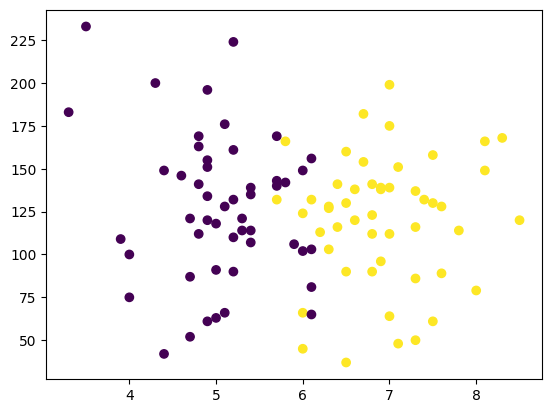

In [75]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [76]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [77]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [78]:
y.shape

(100,)

In [79]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [80]:
X_train

,cgpa,iq
65,8.1,166.0
47,5.2,161.0
16,5.2,224.0
39,4.6,146.0
48,6.6,138.0
...,...,...
33,6.0,149.0
88,4.4,149.0
77,7.3,50.0
6,5.7,143.0


In [81]:
y_train

,placement
65,1
47,0
16,0
39,0
48,1
...,...
33,0
88,0
77,1
6,0


In [82]:
X_test

,cgpa,iq
80,4.9,196.0
24,4.7,121.0
59,4.8,112.0
67,5.0,118.0
9,5.1,66.0
62,6.0,102.0
5,7.1,48.0
11,6.9,138.0
23,4.7,87.0
91,7.5,158.0


In [83]:
from sklearn.preprocessing import StandardScaler

In [84]:
scaler = StandardScaler()

In [85]:
X_train = scaler.fit_transform(X_train)

In [86]:
X_train

array([[ 1.81598293,  1.04939103],
       [-0.7240575 ,  0.92272098],
       [-0.7240575 ,  2.51876366],
       [-1.24958311,  0.54271081],
       [ 0.50216891,  0.34003872],
       [ 1.20286972,  0.18803466],
       [-1.42475831, -2.09202632],
       [-0.8116451 ,  0.08669862],
       [ 1.29045732,  0.13736664],
       [-2.21304672,  2.74676976],
       [-0.8116451 ,  1.30273114],
       [ 1.11528212, -0.21730952],
       [-0.8992327 , -0.85065979],
       [ 2.16633333, -0.11597347],
       [ 0.94010692,  0.66938087],
       [ 0.85251932,  1.88541339],
       [-1.07440791,  0.41604076],
       [-0.7240575 , -0.36931358],
       [-1.77510871, -1.25600396],
       [ 0.41458131,  0.89738696],
       [-2.38822192,  1.48006922],
       [-0.2861195 ,  0.18803466],
       [ 0.06423091, -1.1039999 ],
       [-1.07440791,  1.12539306],
       [ 0.67734411, -0.31864556],
       [ 0.06423091,  0.18803466],
       [ 0.76493172, -0.72398973],
       [ 0.23940611,  0.0613646 ],
       [ 0.15181851,

In [111]:
X_test = scaler.transform(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [112]:
X_test

array([[-10.6590709 ,  -3.23484901],
       [-10.79345809,  -3.23606848],
       [-10.72626449,  -3.23621482],
       [-10.5918773 ,  -3.23611726],
       [-10.5246837 ,  -3.23696277],
       [ -9.91994132,  -3.23637742],
       [ -9.18081175,  -3.23725544],
       [ -9.31519894,  -3.23579207],
       [-10.79345809,  -3.23662131],
       [ -8.91203736,  -3.23546688]])

In [113]:
from sklearn.linear_model import LogisticRegression

In [114]:
clf = LogisticRegression()

In [116]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [117]:
y_pred = clf.predict(X_test)

In [118]:
y_test

,placement
80,0
24,0
59,0
67,0
9,0
62,0
5,1
11,1
23,0
91,1


In [119]:
from sklearn.metrics import accuracy_score

In [121]:
accuracy_score(y_test,y_pred)

0.7

In [122]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

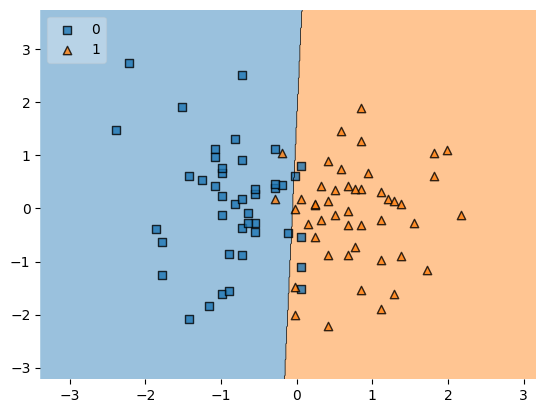

In [123]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [124]:
import pickle

In [125]:
pickle.dump(clf,open('model.pkl','wb'))